In [1]:
import sys
import pandas as pd
import pickle
import importlib
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments
from pm4py.utils import get_properties

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../../')
sys.path.insert(0, '../../../../../')

In [2]:
# log as csv
event_log_path = '../../../../../data/data/helpdesk.csv'
event_log_df = pd.read_csv(event_log_path)

case_id_key='CaseID'
activity_key='Activity'
time_key='CompleteTimestamp'

In [3]:
# load dummy csv with CaseID values to keep
train_csv_path = '../../../data/Helpdesk/raw_data/helpdesk_all_5_train.csv'
val_csv_path = '../../../data/Helpdesk/raw_data/helpdesk_all_5_val.csv'

df_train = pd.read_csv(train_csv_path)
df_val = pd.read_csv(val_csv_path)

# get unique CaseID values
case_ids = sorted(df_train[case_id_key].dropna().unique().tolist()) + sorted(df_val[case_id_key].dropna().unique().tolist())
print(len(case_ids))

# filter event log by these case ids only
df = event_log_df.copy()
df = df[df[case_id_key].isin(set(case_ids))]

rename_map = {}
if case_id_key in df.columns and case_id_key != "case:concept:name":
   rename_map[case_id_key] = "case:concept:name"
if activity_key in df.columns and activity_key != "concept:name":
   rename_map[activity_key] = "concept:name"
if time_key in df.columns and time_key != "time:timestamp":
   rename_map[time_key] = "time:timestamp"

if rename_map:
   df = df.rename(columns=rename_map)

# Ensure timestamp is datetime
if "time:timestamp" in df.columns:
   df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], errors="coerce")

# Sort for determinism (important for trace attribute replication + alignments)
sort_cols = ["case:concept:name"]
if "time:timestamp" in df.columns:
   sort_cols.append("time:timestamp")
df = df.sort_values(sort_cols).reset_index(drop=True)

print(df.head(5))

3664
  case:concept:name           concept:name Resource      time:timestamp  \
0            Case 1     Assign seriousness  Value 1 2012-10-09 14:50:17   
1            Case 1  Take in charge ticket  Value 1 2012-10-09 14:51:01   
2            Case 1  Take in charge ticket  Value 2 2012-10-12 15:02:56   
3            Case 1         Resolve ticket  Value 1 2012-10-25 11:54:26   
4            Case 1                 Closed  Value 3 2012-11-09 12:54:39   

   VariantIndex seriousness customer  product responsible_section  \
0            12     Value 1  Value 1  Value 1             Value 1   
1            12     Value 1  Value 1  Value 1             Value 1   
2            12     Value 1  Value 1  Value 1             Value 1   
3            12     Value 1  Value 1  Value 1             Value 1   
4            12     Value 1  Value 1  Value 1             Value 1   

  seriousness_2 service_level service_type support_section workgroup  
0       Value 1       Value 1      Value 1         Value 1

In [4]:
# Minimal sanity check: timestamps must be datetime + sorted within each case for event_elapsed_time
case_col = "case:concept:name"
ts_col = "time:timestamp"

if ts_col in df.columns:
    is_dt = pd.api.types.is_datetime64_any_dtype(df[ts_col])
    print("time:timestamp is datetime:", is_dt)
    if not is_dt:
        print("WARNING: time:timestamp is not datetime; event_elapsed_time will be wrong")

if case_col in df.columns and ts_col in df.columns:
    neg = df.groupby(case_col)[ts_col].diff() < pd.Timedelta(0)
    n_bad = int(neg.fillna(False).sum())
    print("Out-of-order timestamps (within case):", n_bad)
    if n_bad > 0:
        print("WARNING: df is not sorted within cases; sort upstream before mining")

time:timestamp is datetime: True
Out-of-order timestamps (within case): 0


In [5]:
# import petri net 
petri_net_path = '../../../data/Helpdesk/Petri_net/helpdesk.pkl'
with open(petri_net_path, 'rb') as f:
    net, im, fm = pickle.load(f)

In [6]:
# Input: GenerateTransitionGuards Algorithm
# - N = (P,T,F): A Petri net without data
petri_net=(net, im, fm)

# petri_net = (net, im, fm)
net, im, fm = petri_net

# - EL: event log
event_log_df = df

# - A: A multiset of optimal control-flow alignments of N and an event log
params = get_properties(event_log_df)  # keeps case_id/activity/timestamp keys, etc.
params["ret_tuple_as_trans_desc"] = True

aligned_traces = alignments.apply(event_log_df, net, im, fm, parameters=params)
# get alignments:
alignments = [align_dict['alignment'] for align_dict in aligned_traces]
print(alignments[0:5])

# attributes to be considered for decision mining:
dynamic_attributes = ["Resource",
                      "case_elapsed_time",
                      "event_elapsed_time"]

static_attributes =  ["VariantIndex",
                      "seriousness",
                      "customer",
                      "product",
                      "responsible_section",
                      "seriousness_2",
                      "service_level",
                      "service_type",
                      "support_section",
                      "workgroup"]

aligning log, completed variants ::   0%|          | 0/195 [00:00<?, ?it/s]

[[(('>>', 'skip_2'), ('>>', None)), (('>>', 'init_loop_3'), ('>>', None)), (('>>', 'init_loop_6'), ('>>', None)), (('t_Assign seriousness_0', '168c08ec-40c9-4de7-946e-d548c286df61'), ('Assign seriousness', 'Assign seriousness')), (('>>', 'skip_9'), ('>>', None)), (('>>', 'skip_11'), ('>>', None)), (('t_Take in charge ticket_1', '9db7420f-a35d-4004-85b2-87b8cd721338'), ('Take in charge ticket', 'Take in charge ticket')), (('>>', 'skip_17'), ('>>', None)), (('>>', 'skip_22'), ('>>', None)), (('>>', 'skip_41'), ('>>', None)), (('>>', 'skip_5'), ('>>', None)), (('>>', 'skip_11'), ('>>', None)), (('t_Take in charge ticket_2', '9db7420f-a35d-4004-85b2-87b8cd721338'), ('Take in charge ticket', 'Take in charge ticket')), (('>>', 'skip_17'), ('>>', None)), (('>>', 'tauSplit_23'), ('>>', None)), (('>>', 'skip_27'), ('>>', None)), (('t_Resolve ticket_3', '2fde8823-2049-4b0f-8edd-30f3962b50a6'), ('Resolve ticket', 'Resolve ticket')), (('>>', 'tauSplit_33'), ('>>', None)), (('>>', 'skip_39'), ('>>'

In [7]:
import decision_mining.decision_discovery
import decision_mining.function_estimator_catboost_advanced
importlib.reload(decision_mining.decision_discovery)
importlib.reload(decision_mining.function_estimator_catboost_advanced)
from decision_mining.decision_discovery import DecisionDiscovery
from decision_mining.function_estimator_catboost_advanced import ModelConfig as AdvancedModelConfig

dd = DecisionDiscovery(petri_net=(net, im, fm),
                       sorted_case_ids=case_ids,
                       event_log_df=event_log_df,
                       alignments=alignments)

# Preview generated features per decision place (past-only logic):
feature_previews = dd.debug_feature_preview(dynamic_attributes=dynamic_attributes,
                                            static_attributes=static_attributes,
                                            max_rows_per_place=2,
                                            print_rows=True)

# Tuned CatBoost configuration for decision mining:
# - early stopping cuts runtime substantially
# - no CV calibration by default (CatBoost is usually good enough)
# - surrogate explains true next activities for cleaner guards
# - top-k surrogate features keep guard trees compact and readable
advanced_cfg = AdvancedModelConfig(
    cb_iterations=600,
    cb_learning_rate=0.05,
    cb_depth=6,
    cb_eval_fraction=0.15,
    cb_early_stopping_rounds=80,
    calibrate=False,
    surrogate_target='true_label',
    surrogate_top_k_features=20,
    surrogate_max_depth=5,
    surrogate_min_samples_leaf=40,
    surrogate_pruning_cv=3,
    surrogate_pruning_max_alphas=12,
    min_leaf_prob=0.15,
    min_leaf_lift=1.5,
    min_leaf_support=25,
)
print(advanced_cfg)

res = dd.mine_decision_models(dynamic_attributes=dynamic_attributes,
                              static_attributes=static_attributes,
                              method='advanced',
                              mc_config=advanced_cfg)

# Interpretable probabilistic (set/range-based) guards
guards = dd.extract_guards(mining_result=res,
                           use_advanced_estimator=True)

print("Discovered guards: ", guards)

# User sets only output_dir; save_results writes all artifacts there
result_paths = dd.save_results(
    guards=guards,
    mining_result=res,
    feature_previews=feature_previews,
    output_dir='../../../data/Helpdesk/Petri_net/data_aware_Petri_net',
)

print("Saved outputs:", result_paths)

discovery initialization completed!

=== Feature preview for source (showing 2 row(s)) ===
   past_events_count     target_activity
0                0.0  Assign seriousness
1                0.0  Assign seriousness

=== Feature preview for p_5 (showing 2 row(s)) ===
   past_events_count  older_events_count Resource_prev_event  case_elapsed_time_prev_event  event_elapsed_time_prev_event VariantIndex_prev_event seriousness_prev_event  \
0                0.0                 NaN                 NaN                           NaN                            NaN                     NaN                    NaN   
1                2.0                 1.0             Value 2                     3196606.0                      3196606.0                       1                Value 1   

  customer_prev_event product_prev_event responsible_section_prev_event seriousness_2_prev_event service_level_prev_event service_type_prev_event support_section_prev_event  \
0                 NaN                NaN 


=== source ===
  → Assign seriousness (1 rules)
    * p=0.956; n=3664; lift=1.00
  → Create SW anomaly (1 rules)
    * p=0.000; n=3664; lift=1.00
  → Insert ticket (1 rules)
    * p=0.026; n=3664; lift=1.00
  → Resolve ticket (1 rules)
    * p=0.001; n=3664; lift=1.00
  → Take in charge ticket (1 rules)
    * p=0.016; n=3664; lift=1.00
  → Wait (1 rules)
    * p=0.000; n=3664; lift=1.00

=== p_5 ===
  → Assign seriousness (1 rules)
    * p=0.899; n=3668; lift=1.43; raw_rule=(customer_prev_event=__MISSING__ > 0.5)
  → Create SW anomaly (2 rules)
    * p=0.090; n=1535; lift=11.68; raw_rule=(customer_prev_event=__MISSING__ <= 0.5) AND (VariantIndex_prev3=__MISSING__ > 0.5)
    * p=0.028; n=505; lift=3.62; raw_rule=(customer_prev_event=__MISSING__ <= 0.5) AND (VariantIndex_prev3=__MISSING__ <= 0.5)
  → Resolve ticket (1 rules)
    * p=0.369; n=505; lift=10.02; raw_rule=(customer_prev_event=__MISSING__ <= 0.5) AND (VariantIndex_prev3=__MISSING__ <= 0.5)
  → Take in charge ticket (2 rules)


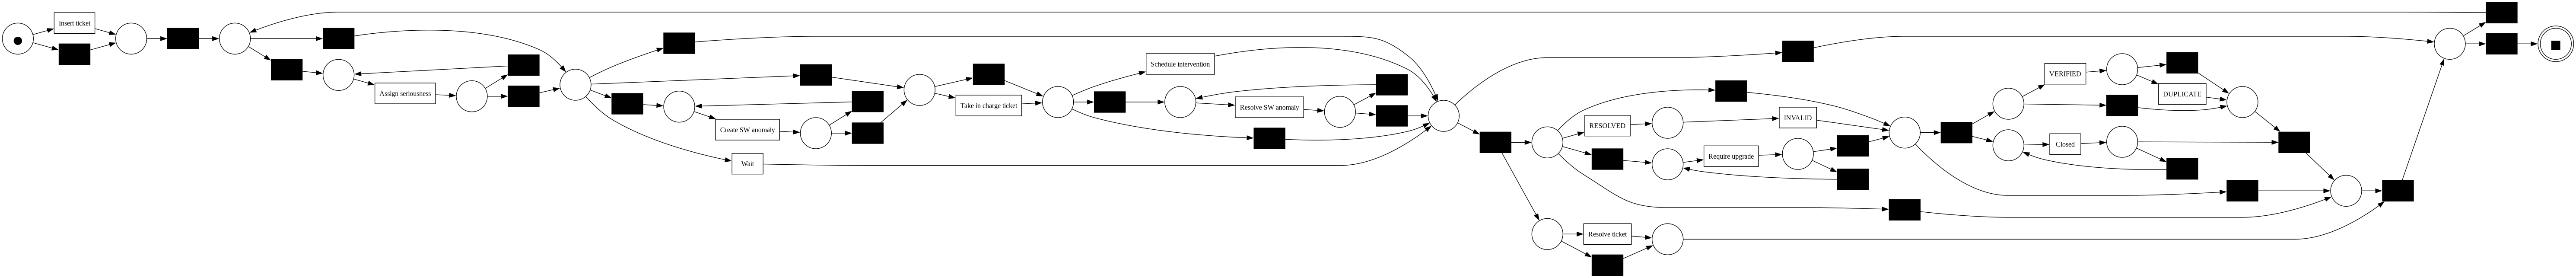

In [8]:
# Petri net visualization with decision rules annotated on places
dd.print_summary_and_visualize(guards=guards)

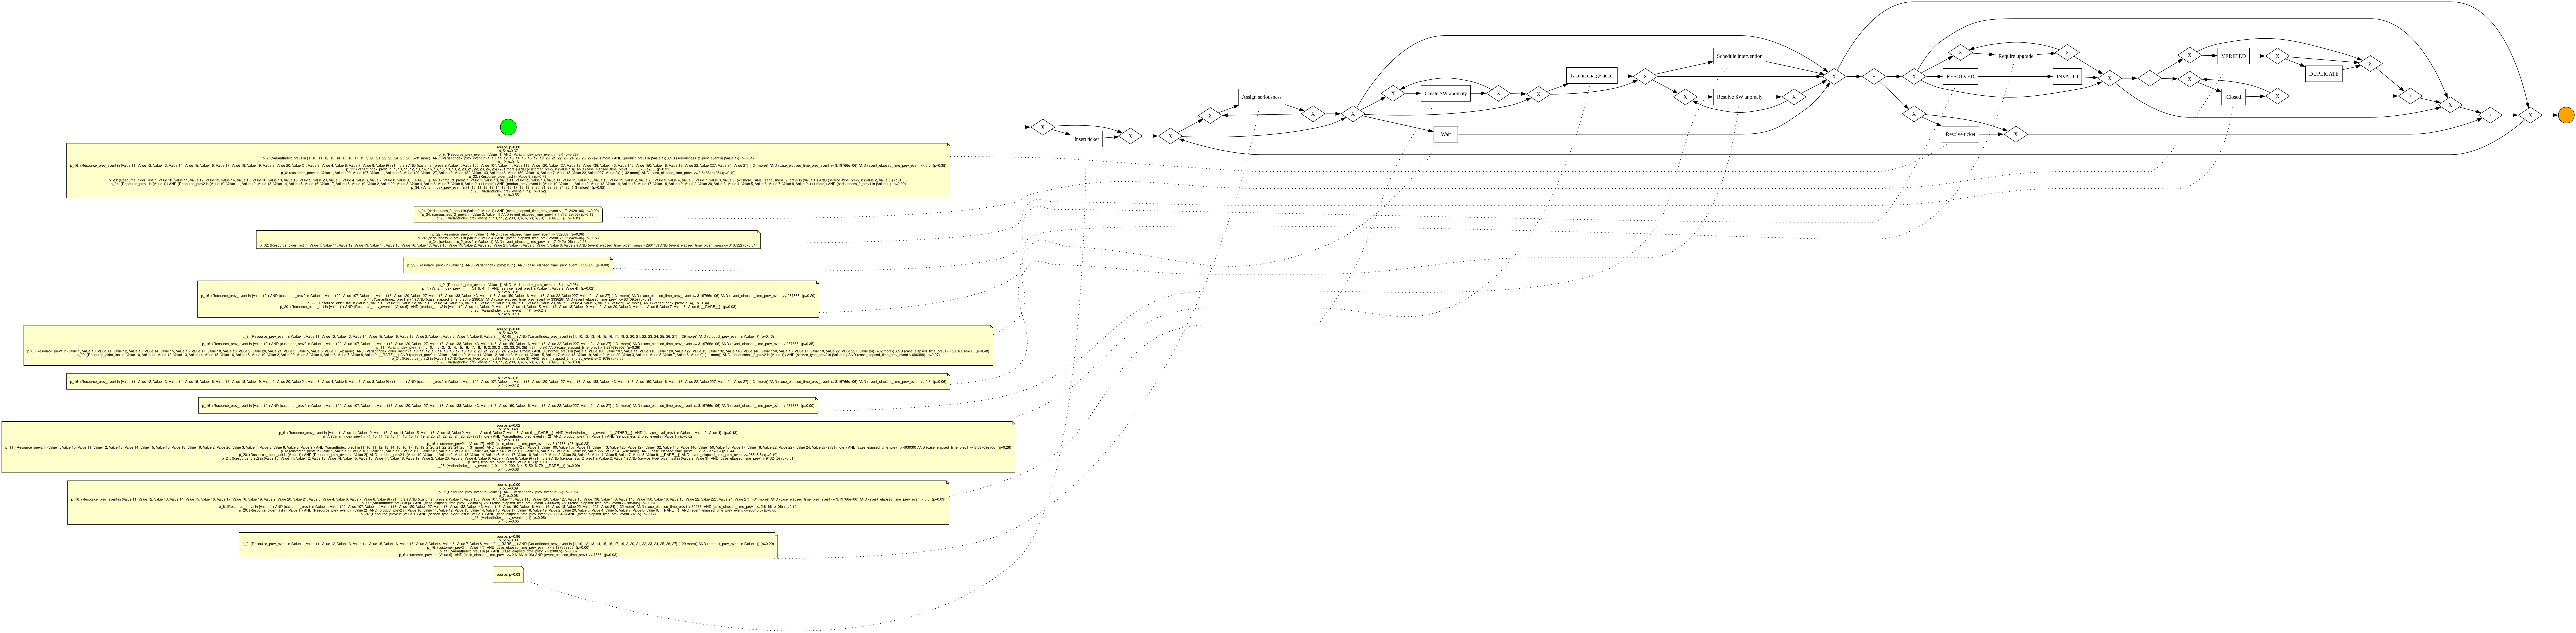

In [9]:
# BPMN visualization with decision rules annotated on exclusive gateways
dd.visualize_bpmn_with_rules(guards=guards)